In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from tqdm import tqdm

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.inverse_problems.ambient_flow import AmbientFlowProblem
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.pullback.standard import StandardPullbackVectorRiemannianAutoencoder
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.parity.tanh import TanhParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

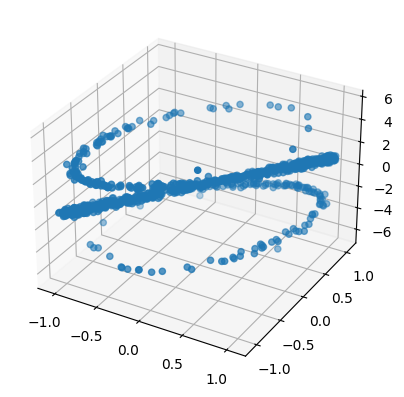

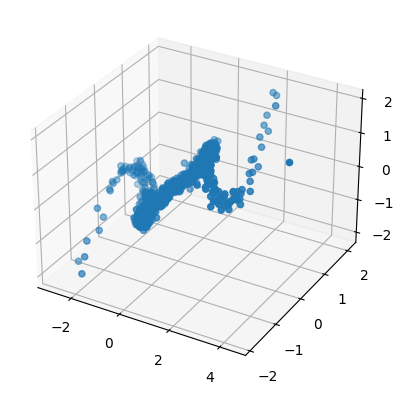

In [2]:
# Construct dataset
def generalised_sinusoid_sampling(dim, latent_dim, num_samples):
    #K the dimension of the manifold
    #N the ambient dimension
    #shearing in the sinusoid formation
    #variances dictate the manifold concentration
    N = dim
    K = latent_dim
    
    # Extract variances for the latent space (manifold) and ambient space
    manifold_variances = 3 * torch.ones(K)
    ambient_variances = 1e-3 * torch.ones(N-K)

    # Sample from the K-dimensional latent space (manifold)
    z_samples = torch.randn(num_samples, K) * torch.sqrt(manifold_variances)

    # Initialize random shears for the off-manifold (N-K) dimensions
    off_manifold_shears = torch.rand(N - K, K) * (2 - 1) + 1  # Random values between [1, 2]

    # Generate the off-manifold samples using the shear vectors and z_samples
    off_manifold_means = []
    for j in range(N - K):
        shear_j = off_manifold_shears[j]  # Get the shear vector for the j-th off-manifold dimension
        off_manifold_mean = torch.sin(z_samples @ shear_j.unsqueeze(1))  # Sinusoidal transformation for off-manifold
        off_manifold_means.append(off_manifold_mean.squeeze(1))  # Squeeze to get correct shape

    # Stack the off-manifold dimensions together
    off_manifold_means = torch.stack(off_manifold_means, dim=1)

    # Generate ambient samples for the remaining (N-K) dimensions
    off_manifold_samples = off_manifold_means + torch.randn(num_samples, N - K) * torch.sqrt(ambient_variances)

    # Combine the manifold and ambient samples
    samples = torch.cat([off_manifold_samples, z_samples], dim=1)
    
    return samples

def random_gaussian_rip(n, m):
    return torch.randn(n, m) / (m**0.5)  # Variance 1/m scaling

dim = 5
num_samples = 1000
noise_level = 0.1

data_clean = generalised_sinusoid_sampling(dim, 1, num_samples)

cor_dim = 3
forward_operator = random_gaussian_rip(cor_dim, dim)

data_train_clean = torch.einsum("nm,Nm->Nn", forward_operator, data_clean) 
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class LinearForward(nn.Module):
    def __init__(self, linear):
        super().__init__()
        self.A = linear

    def forward(self, x):
        return torch.einsum("nm,Nm->Nn", self.A.to(x.device), x) 

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(TanhParityTransform(dim, order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Define the conditional normalizing flow model
def create_conditional_flow_model(dim, cor_dim, n_flows, order, unit_det=False):
    base_dist = distributions.ConditionalDiagonalNormal(shape=[dim], context_encoder=nn.Linear(cor_dim, 2 * dim))
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(TanhParityTransform(dim, order=order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)


In [6]:
# Initialize the model
forward = LinearForward(forward_operator)

n_flows = 6
flow = create_flow_model(dim, n_flows, 2)
prior_diffeo = NFlowVectorDiffeomorphism(dim, flow)

c_flow = create_conditional_flow_model(dim, cor_dim, n_flows, 2)
posterior_diffeo = NFlowVectorDiffeomorphism(dim, c_flow)

model = AmbientFlowProblem(forward, prior_diffeo, posterior_diffeo, noise_level, reg_param=0.1).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [7]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, real_data_reg=None):
    for epoch in range(n_epochs):
        for y in tqdm(train_loader):
            optimizer.zero_grad()
            
            y = y.to(device)
            # Compute loss
            loss = model.reconstruction_loss(y)

            if real_data_reg is not None:
                log_p_theta_gt = model.phi.nflow.log_prob(data_clean[0:10].to(device))
                loss -= real_data_reg * log_p_theta_gt.mean()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [8]:
# Train the model
n_epochs = 250
real_data_reg = 1.
train(model, train_loader, optimizer, n_epochs, real_data_reg=real_data_reg)

  0%|          | 0/8 [00:00<?, ?it/s]/home/wdiepeveen/projects/Score-based-Riemannian-geometry-from-corrupted-data/.venv/lib/python3.8/site-packages/torch/autograd/graph.py:769: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 8/8 [00:08<00:00,  1.00s/it]


Epoch 1/250, Loss: 70.4056


100%|██████████| 8/8 [00:06<00:00,  1.19it/s]


Epoch 2/250, Loss: 58.7544


100%|██████████| 8/8 [00:06<00:00,  1.19it/s]


...

Epoch 248/250, Loss: 1.2011


100%|██████████| 8/8 [00:03<00:00,  2.24it/s]


Epoch 249/250, Loss: 1.5956


100%|██████████| 8/8 [00:06<00:00,  1.32it/s]

Epoch 250/250, Loss: 0.9218


In [9]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [10]:
# Generate conditional samples
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

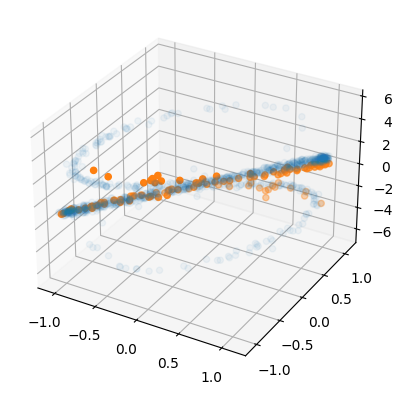

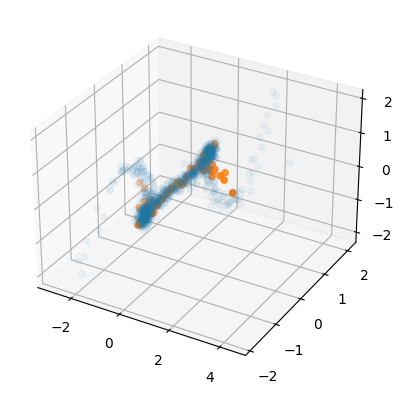

In [11]:
# Visualize generated samples
samples = generate_samples(model.phi.nflow, 100)
cor_samples = torch.einsum("nm,Nm->Nn", forward_operator, samples) 

ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4], alpha=0.05)
ax.scatter(samples[:,2], samples[:,3], samples[:,4])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.05)
ax.scatter(cor_samples[:,0], cor_samples[:,1], cor_samples[:,2])
plt.show()

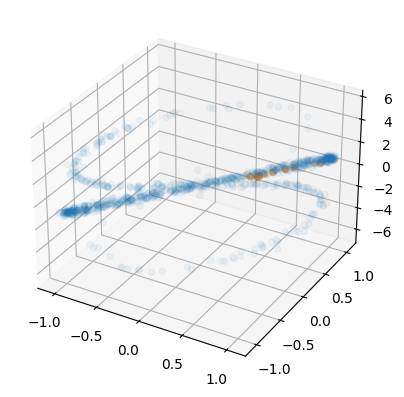

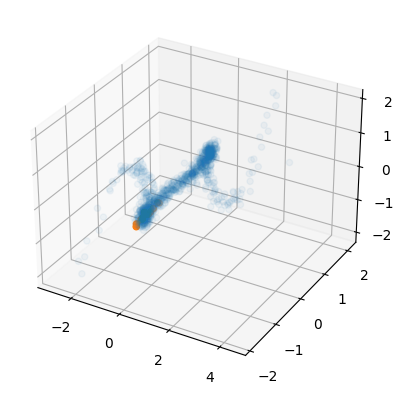

In [12]:
# Visualize generated samples
context = data_train[8]
samples = generate_samples_with_context(model.phy.nflow, 10, context.to(device))
cor_samples = torch.einsum("nm,Nm->Nn", forward_operator, samples) 

ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4], alpha=0.05)
ax.scatter(samples[:,2], samples[:,3], samples[:,4])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.05)
ax.scatter(cor_samples[:,0], cor_samples[:,1], cor_samples[:,2])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Evaluating Geometry ###

In [13]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

##### Standard RAE #####

In [14]:
# Construct RAE
epsilon = 0.1
d_epsilon = 1
rae_ = StandardPullbackVectorRiemannianAutoencoder(manifold, epsilon=epsilon, device=device)
rae = StandardPullbackVectorRiemannianAutoencoder(manifold, d_epsilon=d_epsilon, device=device)

constructed a Riemannian autoencoder with d_eps = 1 and effectice eps = 0.0003113372949883342
constructed a Riemannian autoencoder with d_eps = 1 and effectice eps = 0.0003113372949883342


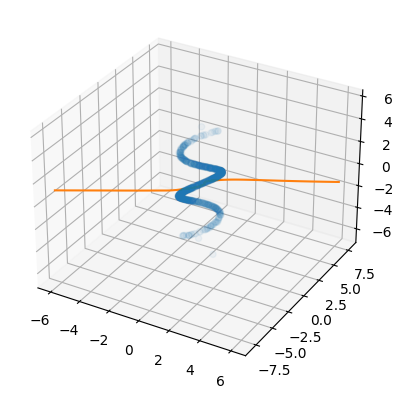

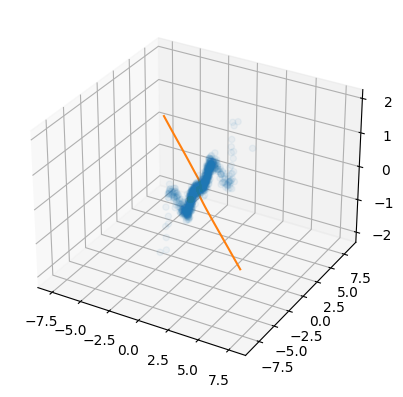

In [15]:
latent_geodesic = torch.linspace(- 5, 5, 100)[:,None].to(device)
geodesic = rae.decode(latent_geodesic).detach().cpu()
cor_geodesic = torch.einsum("nm,Nm->Nn", forward_operator, geodesic) 

ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4], alpha=0.05)
ax.plot(geodesic[:,2].numpy(), geodesic[:,3].numpy(), geodesic[:,4].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.05)
ax.plot(cor_geodesic[:,0].numpy(), cor_geodesic[:,1].numpy(), cor_geodesic[:,2].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(context[0], context[1], context[2])
plt.show()

##### Posterior RAE #####

In [16]:
rec_data_train = torch.zeros(data_train.shape[0], dim)
for i, context in enumerate(data_train):
    samples = generate_samples_with_context(model.phy.nflow, 10, context.to(device))
    rec_data_train[i] = samples.mean(0)

In [17]:
l2_tpca_rae = l2TangentSpacePCAPullbackVectorRiemannianAutoencoder(manifold, rec_data_train.to(device), 1)

constructed a Riemannian autoencoder with latent dimension = 1 and effectice eps = 0.025159701704978943


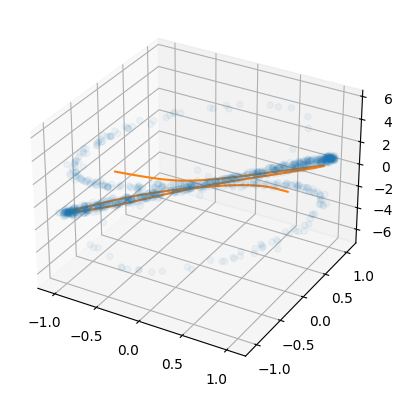

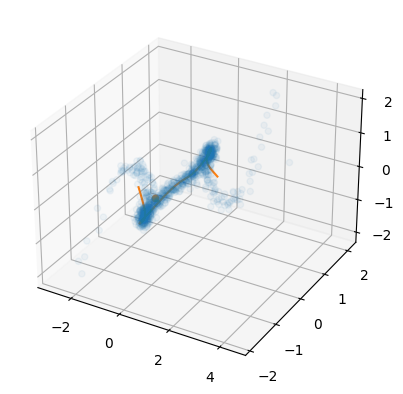

In [18]:
latent_geodesic = torch.linspace(- 15, 15, 100)[:,None].to(device)
l2_tpca_geodesic = l2_tpca_rae.decode(latent_geodesic).detach().cpu()
cor_l2_tpca_geodesic = torch.einsum("nm,Nm->Nn", forward_operator, l2_tpca_geodesic)

ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4], alpha=0.05)
ax.plot(l2_tpca_geodesic[:,2].numpy(), l2_tpca_geodesic[:,3].numpy(), l2_tpca_geodesic[:,4].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.05)
ax.plot(cor_l2_tpca_geodesic[:,0].numpy(), cor_l2_tpca_geodesic[:,1].numpy(), cor_l2_tpca_geodesic[:,2].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Reconstructing the data ###

In [19]:
# TODO implement the reconstruction module in the ambient flow class. Then after training, we should be able to compute the reconstructions and do error analysis